# Human Activity Recognition using Support Vector Machines

## Objective

Build an SVM-based classifier capable of recognizing six different human activities from smartphone sensor data.

This project demonstrates the concepts learned in Chapter 5 of *Hands-On Machine Learning* by Aurélien Géron, including:

- Linear SVM
- RBF Kernel
- Feature Scaling
- Hyperparameter Tuning
- Model Evaluation

## Dataset Overview

The Human Activity Recognition dataset contains smartphone sensor measurements collected while subjects performed daily activities.

Target Classes:

- Walking
- Walking Upstairs
- Walking Downstairs
- Sitting
- Standing
- Laying

In [70]:
import pandas as pd
train = pd.read_csv("/kaggle/input/datasets/organizations/uciml/human-activity-recognition-with-smartphones/train.csv")
test = pd.read_csv("/kaggle/input/datasets/organizations/uciml/human-activity-recognition-with-smartphones/test.csv")
train.shape

(7352, 563)

## Initial Data Inspection

Inspect the dataset structure, feature columns, and target variable.

In [71]:
train.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


In [72]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7352 entries, 0 to 7351
Columns: 563 entries, tBodyAcc-mean()-X to Activity
dtypes: float64(561), int64(1), object(1)
memory usage: 31.6+ MB


## Activity Distribution

Check whether the dataset is balanced across all activity classes.

In [73]:
train["Activity"].value_counts()

Activity
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='Activity'>

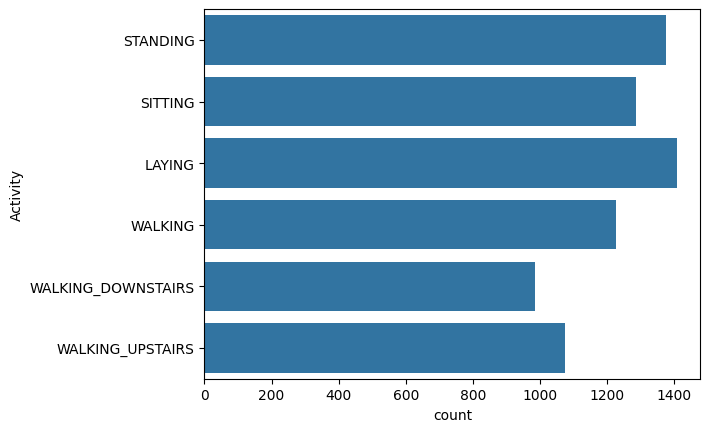

In [74]:
import seaborn as sns
sns.countplot(train["Activity"])

## Preparing Features and Labels

Separate the predictor variables from the target activity labels.

In [75]:
X_train = train.drop(
    ["Activity", "subject"],
    axis=1
)

y_train = train["Activity"]

X_test = test.drop(
    ["Activity", "subject"],
    axis=1
)

y_test = test["Activity"]

In [76]:
X_train.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892


## Baseline Model: Linear Support Vector Machine

Train a Linear SVM to establish a baseline performance.

In [77]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

linear_svm = make_pipeline(
    StandardScaler(),
    SVC(kernel="linear")
)
linear_svm.fit(X_train,y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(kernel='linear'))])

In [78]:
prediction = linear_svm.predict(X_test)

## Baseline Evaluation

Evaluate the Linear SVM using the test dataset.

In [79]:
from sklearn.metrics import accuracy_score
linear_test_acc = accuracy_score(y_test,prediction)
print(linear_test_acc)

0.9606379368849678


## Cross Validation

Estimate the model's generalization performance using 5-fold cross validation.

In [80]:
from sklearn.model_selection import cross_val_score
linear_cv = cross_val_score(
    linear_svm,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)
print(linear_cv)
print("Mean Accuracy:",linear_cv.mean())

[0.92114208 0.89326988 0.94693878 0.94557823 0.96530612]
Mean Accuracy: 0.9344470187803198


## Nonlinear Classification using RBF Kernel

Train an RBF Kernel SVM capable of learning nonlinear decision boundaries.

In [81]:
rbf_svm = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf",C=1,gamma="scale")
)
rbf_svm.fit(X_train,y_train)

Pipeline(steps=[('standardscaler', StandardScaler()), ('svc', SVC(C=1))])

In [82]:
pred = rbf_svm.predict(X_test)
rbf_test_acc = accuracy_score(y_test,pred)
print(rbf_test_acc)

0.9518154054971157


In [83]:
rbf_cv = cross_val_score(
    rbf_svm,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)
print(rbf_cv)
print("Mean Accuracy:",rbf_cv.mean())

[0.91910265 0.89123046 0.9292517  0.9170068  0.95646259]
Mean Accuracy: 0.922610839033098


## Hyperparameter Tuning

Optimize the SVM by searching for the best values of:

- C
- gamma

using GridSearchCV.

In [84]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    "svc__C":[0.1,1,10,100],
    "svc__gamma":[0.001,0.01,0.1,1]
}
grid_search = GridSearchCV(rbf_svm,param_grid,cv=5,
                          scoring="accuracy",
                          return_train_score=True)
grid_search.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('svc', SVC(C=1))]),
             param_grid={'svc__C': [0.1, 1, 10, 100],
                         'svc__gamma': [0.001, 0.01, 0.1, 1]},
             return_train_score=True, scoring='accuracy')

In [85]:
grid_search.best_params_

{'svc__C': 10, 'svc__gamma': 0.001}

In [86]:
grid_search.best_score_

np.float64(0.9340375606394836)

In [87]:
best_model = grid_search.best_estimator_

In [88]:
y_pred = best_model.predict(X_test)
tuned_test_acc = accuracy_score(y_test,y_pred)
print(tuned_test_acc)

0.9548693586698337


In [89]:
tuned_cv = cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)
print(tuned_cv)
print("Mean Accuracy:",tuned_cv.mean())

[0.92522094 0.89870836 0.94353741 0.94217687 0.96054422]
Mean Accuracy: 0.9340375606394836


In [90]:
from sklearn.metrics import precision_score,recall_score,f1_score
print("Precision:",precision_score(y_test,y_pred,average="weighted"))
print("Recall:",recall_score(y_test,y_pred,average="weighted"))
print("F1 Score:",f1_score(y_test,y_pred,average="weighted"))

Precision: 0.9559018425908332
Recall: 0.9548693586698337
F1 Score: 0.9547165939705075


## Error Analysis

Analyze which activities are correctly classified and which activities are frequently confused.

In [91]:
from sklearn.metrics import confusion_matrix
conf_mx = confusion_matrix(y_test,y_pred)
print(conf_mx)

[[537   0   0   0   0   0]
 [  3 433  54   0   0   1]
 [  0  17 515   0   0   0]
 [  0   0   0 486   4   6]
 [  0   0   0   6 389  25]
 [  0   0   0  15   2 454]]


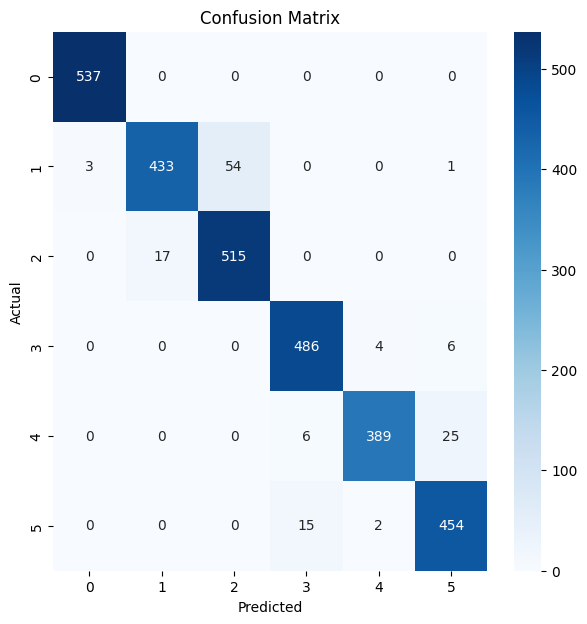

In [92]:
import matplotlib.pyplot as plt 
import seaborn as sns
plt.figure(figsize=(7,7))
sns.heatmap(conf_mx, annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Model Performance Comparison

To summarize the experimental results, we compare the performance of the three SVM models:

- Linear SVM
- RBF Kernel SVM
- Tuned RBF Kernel SVM

Both **Test Accuracy** and **Cross Validation Accuracy** are reported to evaluate predictive performance and generalization ability.

In [93]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Linear SVM",
        "RBF SVM",
        "Tuned RBF SVM"
    ],

    "Test Accuracy": [
        linear_test_acc,
        rbf_test_acc,
        tuned_test_acc
    ],

    "Cross Validation Accuracy": [
        linear_cv.mean(),
        rbf_cv.mean(),
        tuned_cv.mean()
    ]
})

results

,Model,Test Accuracy,Cross Validation Accuracy
0,Linear SVM,0.960638,0.934447
1,RBF SVM,0.951815,0.922611
2,Tuned RBF SVM,0.954869,0.934038


In [94]:
results["Test Accuracy"] = results["Test Accuracy"].round(4)
results["Cross Validation Accuracy"] = results["Cross Validation Accuracy"].round(4)

results

,Model,Test Accuracy,Cross Validation Accuracy
0,Linear SVM,0.9606,0.9344
1,RBF SVM,0.9518,0.9226
2,Tuned RBF SVM,0.9549,0.9340


## Performance Visualization

The following chart provides a visual comparison of the three SVM models.

This makes it easier to identify the impact of introducing nonlinear kernels and hyperparameter tuning on overall model performance.

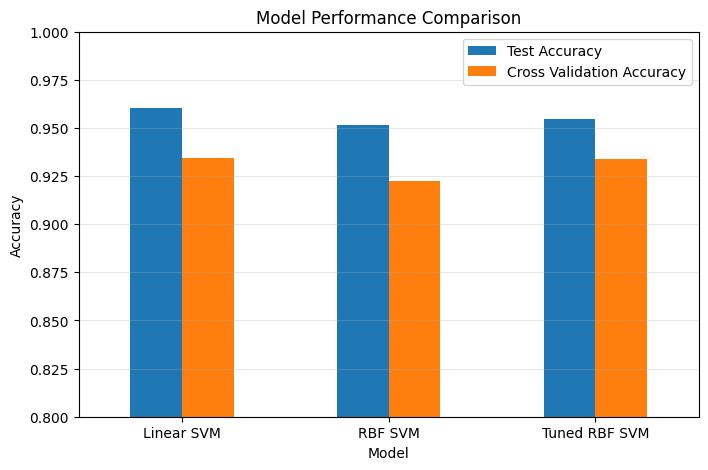

In [95]:
import matplotlib.pyplot as plt

results.plot(
    x="Model",
    y=["Test Accuracy", "Cross Validation Accuracy"],
    kind="bar",
    figsize=(8,5)
)

plt.ylabel("Accuracy")
plt.title("Model Performance Comparison")
plt.xticks(rotation=0)
plt.ylim(0.8, 1.0)
plt.grid(axis="y", alpha=0.3)

plt.show()

# Conclusion

## Project Summary

In this project, Support Vector Machines were successfully applied to classify human activities using smartphone sensor data.

Three different SVM configurations were explored:

- Linear Support Vector Machine
- RBF Kernel Support Vector Machine
- Tuned RBF Kernel SVM using GridSearchCV

The results demonstrate that nonlinear kernels combined with hyperparameter tuning can significantly improve classification performance over a simple linear decision boundary.

## Chapter 5 Concepts Demonstrated

- Support Vector Machines
- Large Margin Classification
- Feature Scaling
- Linear SVM
- RBF Kernel
- Kernel Trick
- Hyperparameter Tuning
- Cross Validation
- GridSearchCV
- Confusion Matrix
- Model Comparison

This project serves as the practical implementation of the concepts introduced in Chapter 5 of *Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow* by Aurélien Géron.